# 03. Counterfactual Analysis

## 📚 Learning Objectives

By completing this notebook, you will:
- Generate and use counterfactual explanations
- Support recourse and understanding of decisions
- Assess counterfactual quality and constraints

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 03. Counterfactual Analysis

## 🚨 THE PROBLEM: We Need "What If" Explanations

**Remember the limitation from the previous notebook?**

We learned LIME for fast, local explanations. But we discovered:

**What if we need to understand what would change a prediction?**

**The Problem**: Sometimes we need:
- ❌ **"What if" scenarios** (what would change the outcome?)
- ❌ **Actionable explanations** (what should I change to get a different result?)
- ❌ **Counterfactual reasoning** (if X had been different, then Y would be different)
- ❌ **Decision guidance** (how to achieve desired outcomes)

**We've learned:**
- ✅ How to use SHAP for explanations (Notebook 1)
- ✅ How to use LIME for fast explanations (Notebook 2)
- ✅ Feature importance and local explanations

**But we haven't learned:**
- ❌ How to generate **counterfactual examples**
- ❌ How to answer **"what if" questions**
- ❌ How to provide **actionable guidance**
- ❌ How to show **what needs to change** for different outcomes

**We need counterfactual analysis** to:
1. Generate "what if" scenarios
2. Show what would change a prediction
3. Provide actionable guidance
4. Enable decision-making support

**This notebook solves that problem** by teaching you counterfactual analysis for "what if" explanations!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding explainability
- ✅ **Example 2: LIME Explanations** - Understanding local explanations
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts

**If you haven't completed these**, you might struggle with:
- Understanding why counterfactuals matter
- Knowing how to generate counterfactual examples
- Understanding what-if analysis

---

## 🔗 Where This Notebook Fits

**This is the THIRD example in Unit 4** - it teaches you "what if" explanations!

**Why this example THIRD?**
- **Before** you can use counterfactuals, you need basic explainability (Examples 1-2)
- **Before** you can ensure accountability, you need multiple explanation methods
- **Before** you can build transparent systems, you need actionable explanations

**Builds on**: 
- 📓 Example 1: SHAP Explanations (feature importance)
- 📓 Example 2: LIME Explanations (local explanations)

**Leads to**: 
- 📓 Example 4: Accountability Frameworks (accountability structures)
- 📓 Example 5: Human-in-the-Loop (HITL approaches)
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. Counterfactuals provide **actionable explanations** (needed for decision-making)
2. Counterfactuals teach **"what if" reasoning** (critical for understanding)
3. Counterfactuals show **decision guidance** (essential for transparency)

---

## The Story: What Would Change the Outcome?

Imagine you're applying for a loan and got rejected. **Before** counterfactuals, you'd know you were rejected but not what to change. **After** using counterfactual analysis, you can see "if your credit score was 50 points higher, you would be approved" - actionable guidance!

Same with AI: **Before** we have explanations but not actionable guidance, now we learn counterfactuals - generate "what if" scenarios to show what would change predictions! **After** counterfactuals, we can provide actionable explanations!

---

## Why Counterfactual Analysis Matters

Counterfactual analysis is essential for ethical AI:
- **Actionable Guidance**: Show what needs to change for different outcomes
- **Decision Support**: Help users understand how to achieve desired results
- **Transparency**: Make AI decisions more understandable through "what if" scenarios
- **Trust**: Build user confidence through actionable explanations
- **Fairness**: Enable users to understand and act on AI decisions

## Learning Objectives
1. Understand counterfactual examples and their meaning
2. Learn how to generate counterfactual examples
3. Perform what-if analysis
4. Provide actionable explanations
5. Visualize counterfactual comparisons
6. Interpret counterfactual results

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

## Part 1: From "Why?" to "What Would It Take?"

SHAP and LIME answer *"why was this decided?"*. A **counterfactual explanation** answers
the question the applicant actually asks: *"what is the smallest change that would flip
the decision?"* We search for minimal single-feature changes that turn a denial into an
approval - that's an *actionable* explanation.

In [1]:
# Build a small loan-approval dataset and train the model we will explain
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 800
X = pd.DataFrame({
    'income':          np.random.normal(55, 18, n).clip(10, 150),     # k$/year
    'debt_ratio':      np.random.uniform(0.05, 0.6, n),               # debt/income
    'years_employed':  np.random.randint(0, 25, n),
    'credit_history':  np.random.normal(650, 80, n).clip(350, 850),   # score
})
score = (0.03*(X['income']-55) - 4.0*(X['debt_ratio']-0.3)
         + 0.05*X['years_employed'] + 0.008*(X['credit_history']-650))
y = (score + np.random.normal(0, 0.35, n) > 0).astype(int)   # 1 = approved

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Loan-approval model trained. Test accuracy: "
      f"{accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"Approval rate in data: {y.mean():.1%}")


Loan-approval model trained. Test accuracy: 0.905
Approval rate in data: 66.0%


In [2]:
# Step 2: Find minimal single-feature counterfactuals for a denied applicant

# Pick a denied applicant
denied_idx = [i for i in range(len(X_test))
              if model.predict(X_test.iloc[[i]])[0] == 0][0]
applicant = X_test.iloc[denied_idx]
proba = model.predict_proba(X_test.iloc[[denied_idx]])[0, 1]
print(f"Denied applicant #{denied_idx} (approval probability {proba:.2f}):")
print(applicant.round(2).to_string())

# Realistic search ranges and directions of change per feature
search_space = {
    'income':         np.linspace(applicant['income'], 150, 200),
    'debt_ratio':     np.linspace(applicant['debt_ratio'], 0.05, 200),
    'years_employed': np.arange(applicant['years_employed'], 26),
    'credit_history': np.linspace(applicant['credit_history'], 850, 200),
}

print("\nSearching for the smallest single-feature change that flips the decision...")
counterfactuals = []
for feat, values in search_space.items():
    for v in values:
        candidate = applicant.copy()
        candidate[feat] = v
        if model.predict(pd.DataFrame([candidate]))[0] == 1:
            counterfactuals.append(
                {'feature': feat, 'from': applicant[feat], 'to': v,
                 'change': abs(v - applicant[feat]),
                 'relative_change': abs(v - applicant[feat])
                                    / max(abs(applicant[feat]), 1e-9)})
            break   # first (smallest) flip for this feature

if not counterfactuals:
    print("No single-feature change flips this decision within realistic ranges -")
    print("this applicant would need to improve on several features at once.")
else:
    cf_df = pd.DataFrame(counterfactuals).sort_values('relative_change')
    print("\nCounterfactuals found (sorted by smallest relative change):")
    for _, r in cf_df.iterrows():
        print(f"  {r['feature']:<15} {r['from']:8.2f} -> {r['to']:8.2f} "
              f"(change {r['change']:.2f}, {r['relative_change']:.1%} relative)")
    best = cf_df.iloc[0]
    print(f"\nACTIONABLE EXPLANATION for the applicant:")
    print(f'  "Your loan would have been approved if your {best["feature"]} were')
    print(f'   {best["to"]:.2f} instead of {best["from"]:.2f}."')

print("\nAssessing counterfactual quality (the criteria that matter):")
print("  - Validity: does it actually flip the model's decision? (checked above)")
print("  - Proximity: is the change small? (we picked the smallest per feature)")
print("  - Plausibility: is it realistic? (we bounded the search to real ranges,")
print("    and only moved features in achievable directions)")
print("  - Actionability: CAN the person change it? (income yes; age-like")
print("    features would not be - choose counterfactual features with care)")


Denied applicant #0 (approval probability 0.15):
income             64.27
debt_ratio          0.41
years_employed      5.00
credit_history    503.33

Searching for the smallest single-feature change that flips the decision...



Counterfactuals found (sorted by smallest relative change):
  credit_history    503.33 ->   618.31 (change 114.98, 22.8% relative)
  debt_ratio          0.41 ->     0.25 (change 0.16, 39.7% relative)

ACTIONABLE EXPLANATION for the applicant:
  "Your loan would have been approved if your credit_history were
   618.31 instead of 503.33."

Assessing counterfactual quality (the criteria that matter):
  - Validity: does it actually flip the model's decision? (checked above)
  - Proximity: is the change small? (we picked the smallest per feature)
  - Plausibility: is it realistic? (we bounded the search to real ranges,
    and only moved features in achievable directions)
  - Actionability: CAN the person change it? (income yes; age-like
    features would not be - choose counterfactual features with care)


## Part 2: Visualizing the Counterfactual Comparison

One applicant can have several possible paths to approval. A small chart comparing the
relative change each path requires shows instantly which recourse is *cheapest* - exactly
the comparison you would put in front of a loan officer or the applicant.

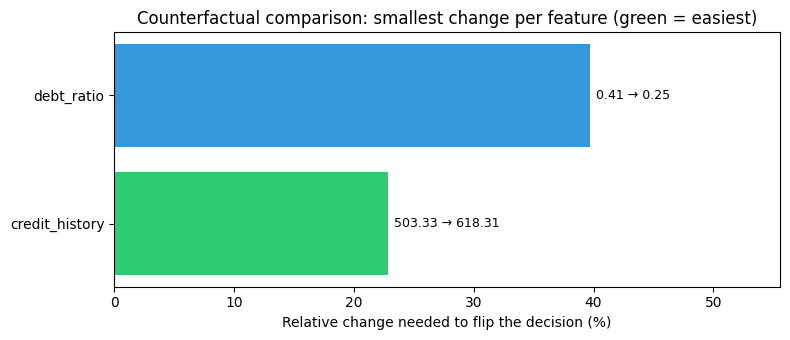

Reading the chart: EVERY bar flips the denial into an approval;
the green (shortest) bar is the least-effort recourse to recommend.


In [3]:
# Step 3: Visualize the counterfactual comparisons found in Step 2
# WHY: a chart makes the "cost" of each path to approval visible at a glance -
# the shortest bar is the cheapest, most actionable change for this applicant.
import matplotlib.pyplot as plt

if counterfactuals:
    # Sort so the smallest (easiest) relative change is the first bar
    plot_df = cf_df.sort_values('relative_change', ascending=True)

    # One horizontal bar per feature: relative change needed to flip the decision
    fig, ax = plt.subplots(figsize=(8, 3.5))
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(plot_df))]
    ax.barh(plot_df['feature'], plot_df['relative_change'] * 100, color=colors)

    # Annotate each bar with the concrete change it represents (from -> to)
    for y, (_, r) in enumerate(plot_df.iterrows()):
        ax.text(r['relative_change'] * 100 + 0.5, y,
                f"{r['from']:.2f} → {r['to']:.2f}", va='center', fontsize=9)

    # Label the chart so it reads on its own
    ax.set_xlabel('Relative change needed to flip the decision (%)')
    ax.set_title('Counterfactual comparison: smallest change per feature (green = easiest)')
    ax.set_xlim(0, plot_df['relative_change'].max() * 100 * 1.4)
    plt.tight_layout()
    plt.show()

    print("Reading the chart: EVERY bar flips the denial into an approval;")
    print("the green (shortest) bar is the least-effort recourse to recommend.")
else:
    # Honest fallback: with no counterfactuals found there is nothing to chart
    print("No single-feature counterfactual was found, so there is nothing to chart.")

---

## 🚫 When Counterfactual Analysis Hits a Limitation

### The Limitation We Discovered

We've learned counterfactual analysis for "what if" explanations. **But there's still a challenge:**

**How do we ensure accountability and responsibility for AI decisions?**

Counterfactual analysis works well when:
- ✅ We can generate "what if" scenarios
- ✅ We can provide actionable guidance
- ✅ We can explain what would change outcomes

**But transparent AI systems also need:**
- ❌ **Accountability frameworks** (who is responsible?)
- ❌ **Responsibility mechanisms** (how to assign responsibility?)
- ❌ **Audit trails** (how to track decisions?)
- ❌ **Stakeholder accountability** (who answers for outcomes?)

### Why This Is a Problem

When we have explanations but no accountability:
- We may not know who is responsible for AI decisions
- We may not have mechanisms to track and audit decisions
- We may not have clear responsibility structures
- We may not be able to hold anyone accountable

### The Solution: Accountability Frameworks

We need **accountability frameworks** to:
1. Define stakeholder responsibilities
2. Create audit trails
3. Establish responsibility mechanisms
4. Enable accountability for AI decisions

**This is exactly what we'll learn in the next notebook: Accountability Frameworks!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP for explanations (Notebook 1)
- ✅ How to use LIME for fast explanations (Notebook 2)
- ✅ How to use counterfactuals for "what if" scenarios (This notebook!)
- ✅ **The limitation**: We need accountability frameworks!

**Next notebook**: `04_accountability_frameworks.ipynb`
- Learn about accountability frameworks
- Understand stakeholder responsibilities
- Create audit trails
- Establish responsibility mechanisms